# Multi-Layer Neural Network

Goal: move from a single linear layer to a small neural network with hidden layers and activation functions.

Learning Objectives:
- hidden layers
- ReLU
- forward propagation through multiple layers
- model capacity
- train vs validation loss
- overfitting intuition

In [4]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# nonlinear dataset generation

torch.manual_seed(42)


x = torch.linspace(-3, 3, 1000).reshape(-1, 1)

y = (
    0.5 * x**3
    - 2 * x**2
    + x
    + 3
)

y += 0.5 * torch.randn_like(y)

print(x.shape)
print(y.shape)

torch.Size([1000, 1])
torch.Size([1000, 1])


In [5]:
# training test split

dataset = TensorDataset(x, y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [6]:
# define the neural network architecture

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 16), # 1 input feature, 16 output (neurons) features
            nn.ReLU(), # activation function (so linear layers dont collapse into a single linear layer)

            nn.Linear(16, 8), # 16 input features, 8 output (neurons) features
            nn.ReLU(),

            nn.Linear(8, 1) # 8 input features, 1 output (neurons) features
        )

    def forward(self, x):
        return self.network(x)

In [7]:
# instantiate the model and move it to the appropriate device (GPU if available, otherwise CPU)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [8]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [9]:
epochs = 500

for epoch in range(epochs):

    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = model(xb)

        loss = criterion(predictions, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            predictions = model(xb)

            loss = criterion(predictions, yb)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch    0 | Train Loss: 82.1361 | Val Loss: 89.5097
Epoch   50 | Train Loss: 1.2703 | Val Loss: 1.4187
Epoch  100 | Train Loss: 0.3614 | Val Loss: 0.4377
Epoch  150 | Train Loss: 0.2940 | Val Loss: 0.3167
Epoch  200 | Train Loss: 0.2691 | Val Loss: 0.3240
Epoch  250 | Train Loss: 0.2685 | Val Loss: 0.3017
Epoch  300 | Train Loss: 0.2672 | Val Loss: 0.3009
Epoch  350 | Train Loss: 0.2661 | Val Loss: 0.3018
Epoch  400 | Train Loss: 0.2622 | Val Loss: 0.3127
Epoch  450 | Train Loss: 0.2649 | Val Loss: 0.3132


In [10]:
# training loss improving while validation loss increasing is a sign of overfitting

In [11]:
x_plot = torch.linspace(-3, 3, 500).reshape(-1, 1) # dense set of values covering same range as dataset

In [12]:
# using trained model to predict x_plot

model.eval()

# compute on gpu
with torch.no_grad():
    x_plot_gpu = x_plot.to(device)
    y_plot = model(x_plot_gpu)

# output to cpu for matplotlib to plot
y_plot = y_plot.cpu()

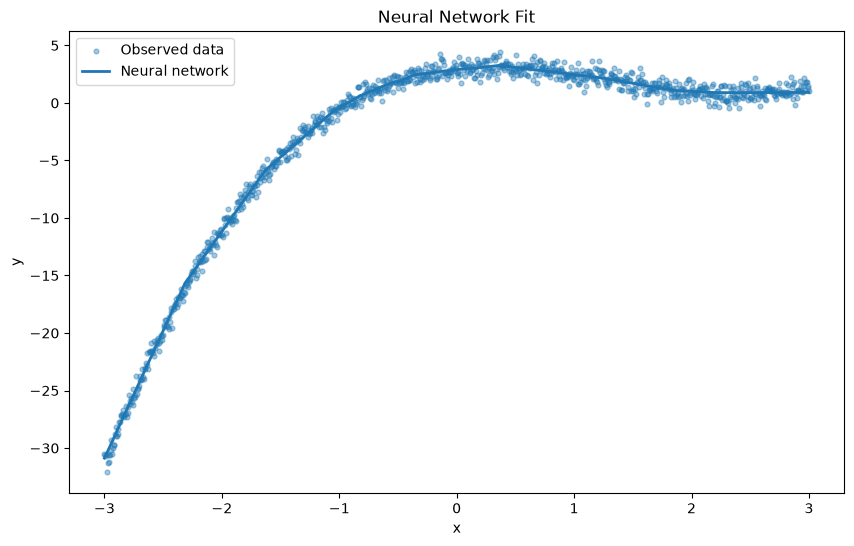

In [13]:
# neural network fit plot, dots = observed data, line = neural net output

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    x.numpy(),
    y.numpy(),
    s=12,
    alpha=0.4,
    label="Observed data"
)

plt.plot(
    x_plot.numpy(),
    y_plot.numpy(),
    linewidth=2,
    label="Neural network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network Fit")
plt.legend()

plt.show()

## Overfitting experiment
Deliberately Overfitting a Neural Network

In [14]:
# fewer observations and more noise

torch.manual_seed(42)

x_overfit = torch.linspace(-3, 3, 120).reshape(-1, 1)

y_overfit = (
    0.5 * x_overfit**3
    - 2 * x_overfit**2
    + x_overfit
    + 3
)

y_overfit += 1.5 * torch.randn_like(y_overfit)

print(x_overfit.shape)
print(y_overfit.shape)

torch.Size([120, 1])
torch.Size([120, 1])


In [15]:
# training set intentionally small

overfit_dataset = TensorDataset(
    x_overfit,
    y_overfit
)

train_size = 60
val_size = 60

overfit_train, overfit_val = random_split(
    overfit_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [16]:
overfit_train_loader = DataLoader(
    overfit_train,
    batch_size=10,
    shuffle=True
)

overfit_val_loader = DataLoader(
    overfit_val,
    batch_size=10,
    shuffle=False
)

In [17]:
# network that is comically too large for the problem

class LargeNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [18]:
large_model = LargeNeuralNetwork().to(device)

print(large_model)

LargeNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [19]:
total_parameters = sum(
    p.numel()
    for p in large_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_parameters)

Trainable parameters: 107521


In [20]:
# way more trainable parameters than training observations

In [21]:
# recording loss every epoch

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    large_model.parameters(),
    lr=0.001
)

epochs = 1500

train_losses = []
val_losses = []

In [22]:
# training loop

for epoch in range(epochs):

    # -------------------
    # Training
    # -------------------

    large_model.train()
    train_loss = 0.0

    for xb, yb in overfit_train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = large_model(xb)

        loss = criterion(predictions, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(overfit_train_loader)

    # -------------------
    # Validation
    # -------------------

    large_model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for xb, yb in overfit_val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            predictions = large_model(xb)

            loss = criterion(predictions, yb)

            val_loss += loss.item()

    val_loss /= len(overfit_val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch    0 | Train Loss: 91.1611 | Val Loss: 74.1516


Epoch  100 | Train Loss: 1.6147 | Val Loss: 2.8324
Epoch  200 | Train Loss: 1.2445 | Val Loss: 2.9184
Epoch  300 | Train Loss: 1.0767 | Val Loss: 3.3616
Epoch  400 | Train Loss: 1.0751 | Val Loss: 3.2407
Epoch  500 | Train Loss: 0.8014 | Val Loss: 3.5132
Epoch  600 | Train Loss: 0.7276 | Val Loss: 3.2444
Epoch  700 | Train Loss: 0.7806 | Val Loss: 3.3937
Epoch  800 | Train Loss: 0.7641 | Val Loss: 3.6027
Epoch  900 | Train Loss: 0.7174 | Val Loss: 3.0784
Epoch 1000 | Train Loss: 0.7205 | Val Loss: 3.3687
Epoch 1100 | Train Loss: 1.1836 | Val Loss: 4.8051
Epoch 1200 | Train Loss: 0.6553 | Val Loss: 3.2858
Epoch 1300 | Train Loss: 0.7555 | Val Loss: 3.0925
Epoch 1400 | Train Loss: 0.6703 | Val Loss: 3.5596


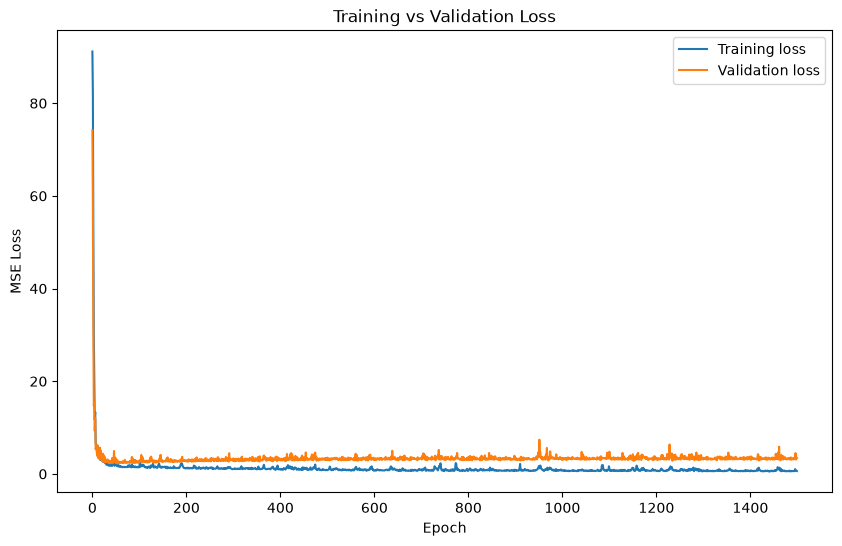

In [23]:
# plot training loss vs validation loss

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training loss"
)

plt.plot(
    val_losses,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [24]:
x_plot = torch.linspace(-3, 3, 500).reshape(-1, 1)

large_model.eval()

with torch.no_grad():
    y_large = large_model(
        x_plot.to(device)
    ).cpu()

In [25]:
y_true = (
    0.5 * x_plot**3
    - 2 * x_plot**2
    + x_plot
    + 3
)

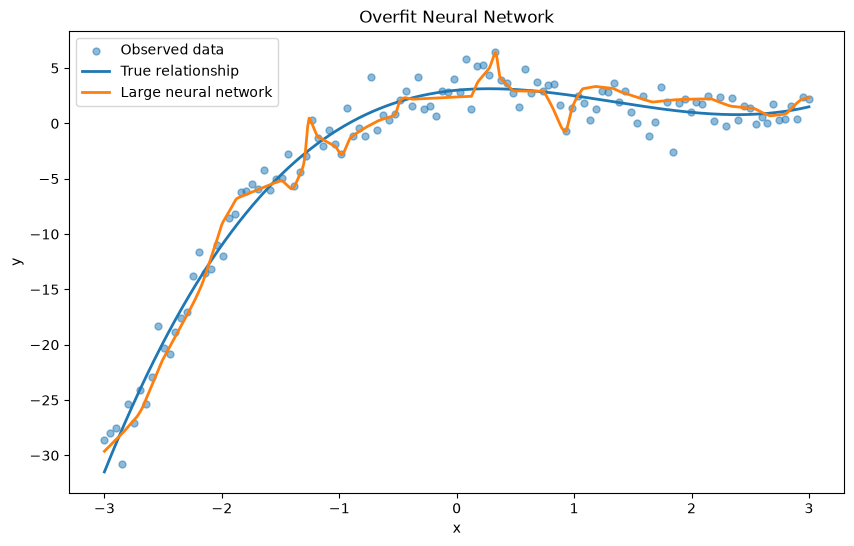

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_overfit.numpy(),
    y_overfit.numpy(),
    s=25,
    alpha=0.5,
    label="Observed data"
)

plt.plot(
    x_plot.numpy(),
    y_true.numpy(),
    linewidth=2,
    label="True relationship"
)

plt.plot(
    x_plot.numpy(),
    y_large.numpy(),
    linewidth=2,
    label="Large neural network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Overfit Neural Network")
plt.legend()

plt.show()

In [27]:
# notes
# visual representation of overfitting = learned curve becomes super wiggly
# quant representation = training improves, validation gets worse

## Early Stopping

#### method of model improvement

idea : Keep training while validation loss improves. If it stops improving for long enough, stop and restore the best model.

In [29]:
large_model = LargeNeuralNetwork().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    large_model.parameters(),
    lr=0.001
)

In [31]:
epochs = 1500
patience = 100  # if validation loss fails to improve for 100 consecutive epochs, stop training.

best_val_loss = float("inf")
epochs_without_improvement = 0

best_model_state = None

train_losses = []
val_losses = []

In [32]:
for epoch in range(epochs):

    # -------------------
    # Training
    # -------------------

    large_model.train()
    train_loss = 0.0

    for xb, yb in overfit_train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = large_model(xb)

        loss = criterion(predictions, yb)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(overfit_train_loader)

    # -------------------
    # Validation
    # -------------------

    large_model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for xb, yb in overfit_val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            predictions = large_model(xb)

            loss = criterion(predictions, yb)

            val_loss += loss.item()

    val_loss /= len(overfit_val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # -------------------
    # Early stopping
    # -------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        best_model_state = {
            key: value.clone()
            for key, value in large_model.state_dict().items()
        }

    else:

        epochs_without_improvement += 1

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break

Epoch    0 | Train Loss: 90.3204 | Val Loss: 71.8017
Epoch  100 | Train Loss: 1.4396 | Val Loss: 2.6259

Early stopping at epoch 173


In [33]:
large_model.load_state_dict(best_model_state)

print("Best validation loss:", best_val_loss)

Best validation loss: 2.2280001839001975


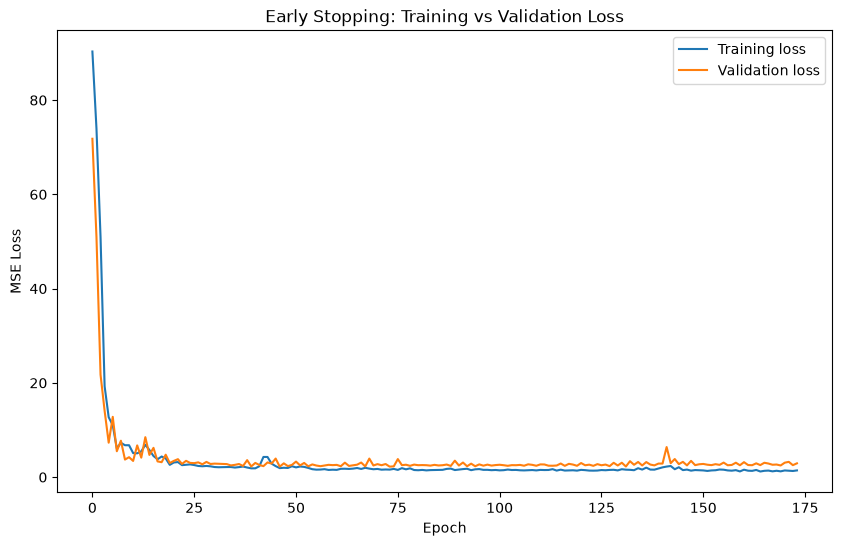

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training loss"
)

plt.plot(
    val_losses,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Early Stopping: Training vs Validation Loss")
plt.legend()

plt.show()

In [35]:
large_model.eval()

with torch.no_grad():
    y_early_stop = large_model(
        x_plot.to(device)
    ).cpu()

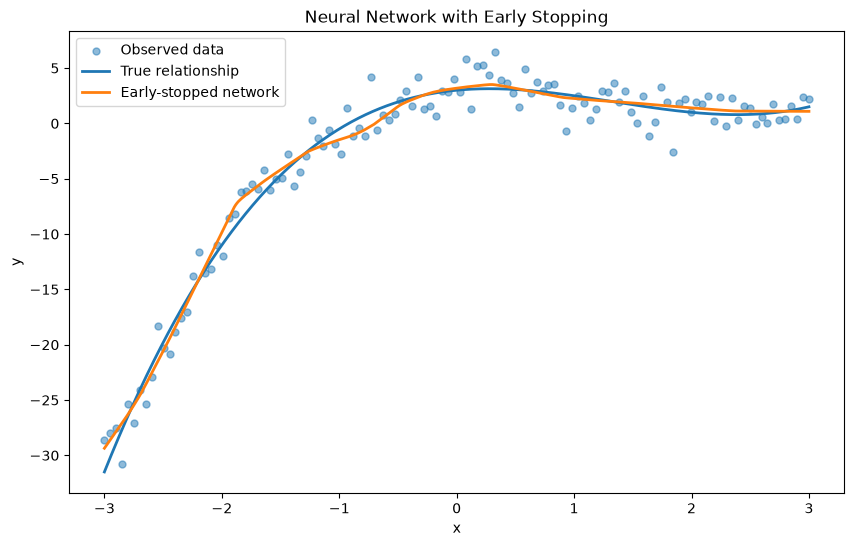

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_overfit.numpy(),
    y_overfit.numpy(),
    s=25,
    alpha=0.5,
    label="Observed data"
)

plt.plot(
    x_plot.numpy(),
    y_true.numpy(),
    linewidth=2,
    label="True relationship"
)

plt.plot(
    x_plot.numpy(),
    y_early_stop.numpy(),
    linewidth=2,
    label="Early-stopped network"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural Network with Early Stopping")
plt.legend()

plt.show()

In [38]:
# training loss keeps improving
#         ↓
# validation loss reaches its best point
#         ↓
# validation loss starts worsening
#         ↓
# wait for patience window
#         ↓
# stop training
#         ↓
# restore best model